In [ ]:
import os
import matplotlib.pyplot as plt
from warnings import filters
import jax.numpy as jnp
import jax
from caskade import Param, forward
import numpy as np
import pandas as pd

# from cosmographi.source.base import TransientSource




from tinygp import GaussianProcess, kernels


import jaxopt



The first step is going to be to try to build the kernel. 

In [25]:
# the first step is going to be to try to build the kernel
sigma = Param("sigma", shape=(), description="sigma parameter")
scale = Param("scale", shape=(), description="scale parameter")
kernel = kernels.quasisep.Exp(scale=scale, sigma=sigma)

#TODO: REMEMBER THIS PROCESS GIVES YOU THE FLUX DON'T FORGET TO CONVERT

It would now be nice to have some data to condition or gp likelihood on. I am especialy interested in sepparating different objects vs different time stamps of the same object (#TODO read up on time series analysis). 
To get around this and figure out how to use tinygo before tsa, I will try to infer the hyperparameters of the kernel for each object 
sepparatly. Then, I will look at the distirbution of the hyperparameters, and to generate new lightcurves I will sample from said
distribution of hyperparameters and plug in into a gp to generate the luminosity at different time stamps.
To save time on the data acquisition, I will follow the extremly scientific method of eyeballing datapoints from the lightcurves published in this paper: https://arxiv.org/pdf/1803.06436. (#TODO get better data). Note that there is also bias in terms of what points I included in my data. 


In [26]:
# Our next step is to prep our extremly scientific and accurate  and not sketchy at all data 

df = pd.read_csv("bad_agn_data.csv")
source_1 = jnp.asarray(df[df['source'] == 1].to_numpy())
source_2 = jnp.asarray(df[df['source'] == 2].to_numpy())
source_3 = jnp.asarray(df[df['source'] == 3].to_numpy())
source_4 = jnp.asarray(df[df['source'] == 4].to_numpy())
source_5 = jnp.asarray(df[df['source'] == 5].to_numpy())

print(source_1)

print(source_1[:, 1])
print(source_1[:, 2])

[[    1     0 14475]
 [    1    50 14500]
 [    1   100 14450]
 [    1   200 14460]
 [    1   300 14465]
 [    1   400 14473]
 [    1   500 14532]
 [    1   600 14510]
 [    1   700 14450]
 [    1   800 14525]
 [    1   900 14525]]
[  0  50 100 200 300 400 500 600 700 800 900]
[14475 14500 14450 14460 14465 14473 14532 14510 14450 14525 14525]


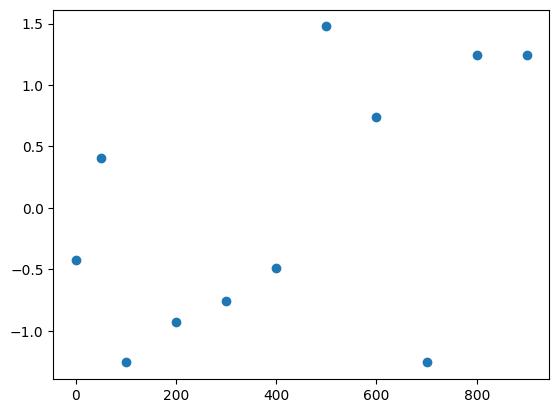

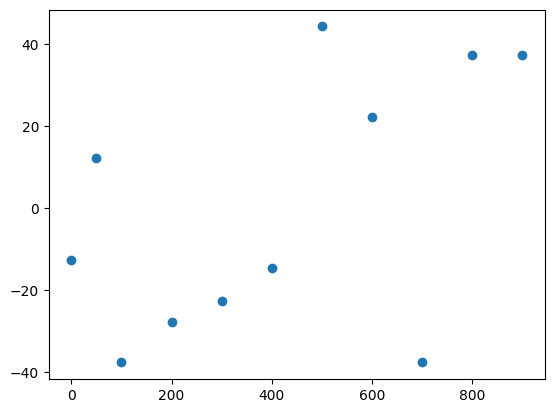

In [27]:
y_mean = jnp.mean(source_1[:, 2])
y_sd = jnp.std(source_1[:, 2])
y_standarized = (source_1[:, 2] - y_mean) / y_sd

plt.scatter(source_1[:, 1], y_standarized)
plt.show()

plt.scatter(source_1[:, 1], source_1[:, 2] - y_mean)
plt.show()

In [28]:
def build_gp(theta: tuple[Param], x: jnp.ndarray) -> GaussianProcess:
    """ Build a Gaussian Process with the given parameters and input data.
    Precondition: theta is a tuple of (log_sigma, log_scale, log_noise) parameters.
    """
    log_sigma, log_scale, log_noise = theta
    kernel = kernels.quasisep.Exp(scale=jnp.exp(log_scale), sigma=jnp.exp(log_sigma))
    return GaussianProcess(kernel, x, diag=jnp.exp(log_noise)**2)

(Array(-1.4893993, dtype=float32), Array(4.5859184, dtype=float32), Array(-0.02602488, dtype=float32))


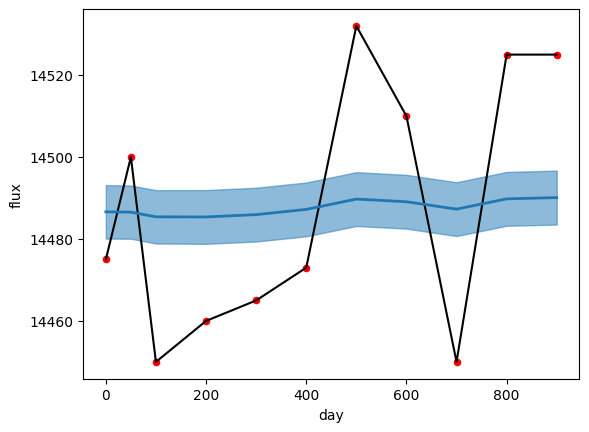

In [29]:
# Before circling over all samples, I want to test if it works for just one. 
# I will pick some bad values to initialize the gaussian process #TODO: FIgrue out how to pick good ones
scale = Param("scale", value=200.0, shape=(), description="scale parameter")
sigma = Param("sigma", value=35.0, shape=(), description="sigma parameter")
noise = Param("noise", value=10.0, shape=(), description="noise parameter")

theta = (jnp.log(float(sigma.value)), jnp.log(float(scale.value)), jnp.log(float(noise.value)))


def neg_log_likelihood(theta, X, y):
    gp = build_gp(theta, X)
    return -gp.log_probability(y)

solver = jaxopt.ScipyMinimize(fun=neg_log_likelihood)
soln = solver.run(theta, X=source_1[:, 1], y=y_standarized)

gp = build_gp(soln.params, source_1[:, 1])

print(soln.params)

cond_gp = gp.condition(y_standarized).gp


mu, var = cond_gp.loc, cond_gp.variance



plt.plot(source_1[:, 1], source_1[:, 2], color = "k")
plt.scatter(source_1[:, 1], source_1[:, 2], color="red", s=20)
plt.fill_between(source_1[:, 1], y_mean + y_sd * (mu + np.sqrt(var)), y_mean + y_sd * (mu - np.sqrt(var)), color="C0", alpha=0.5)
plt.plot(source_1[:, 1], y_mean + y_sd * mu, color="C0", lw=2)
# plt.xlim(source_1[:, 1].min(), 1000)
plt.xlabel("day")
_ = plt.ylabel("flux")

The reuslt is very obviously very bad. I am, however, usure if this is a gp process. As we can see from the scatterplots above, the information content was probably pretty low, it does just look like random noise. In retrospect, I should have simulated the data the same way I did for the dummy AGN models in agn_simplified.ipynb. 

That is what we are going to try next. After this, I will try using some real (or ar least more accirately simulated) data. 

0.013112576


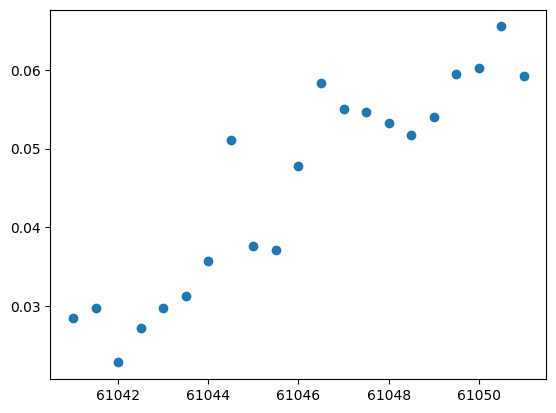

In [30]:
from astropy.time import Time

t_i = Time("2026-01-01T00:00:00").mjd
sample_times = jnp.array([t_i + 0.0, t_i + 0.5, t_i + 1.0, t_i + 1.5, t_i + 2.0, t_i + 2.5, t_i + 3.0, t_i + 3.5, t_i + 4.0, t_i + 4.5, 
                         t_i + 5.0, t_i + 5.5, t_i + 6.0, t_i + 6.5, t_i + 7.0, t_i + 7.5, t_i + 8.0, t_i + 8.5, t_i + 9.0, t_i + 9.5, t_i + 10.0])
a = 0.02
d = 0.04
true_b_value = 0.25
true_c_value = t_i - 0.6
non_lin_samples = []
for time in sample_times:
    non_lin_samples.append(np.random.normal(loc=a*np.sin(true_b_value * time - true_c_value) + d, scale = 0.005))
samples_jnp_non_lin = jnp.array(non_lin_samples)

plt.scatter(sample_times, samples_jnp_non_lin)

print(jnp.std(samples_jnp_non_lin))

(Array(-3.0560043, dtype=float32), Array(4.352047, dtype=float32), Array(-5.900743, dtype=float32))
[0.02845044 0.02860832 0.02458329 0.02717609 0.02967505 0.03201773
 0.03694614 0.04668812 0.03949124 0.03934991 0.04771463 0.05592868
 0.05513605 0.05453932 0.05330713 0.05246788 0.05454019 0.05880845
 0.06059406 0.06372204 0.06003465]


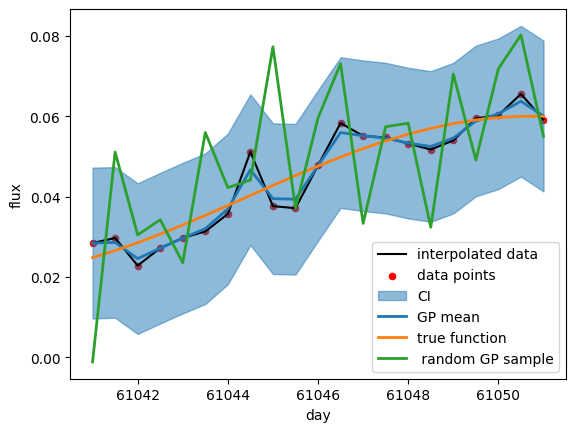

In [31]:
scale = Param("scale", value=2.0, shape=(), description="scale parameter")
sigma = Param("sigma", value=0.012, shape=(), description="sigma parameter")
noise = Param("noise", value=0.005, shape=(), description="noise parameter")

theta = (jnp.log(float(sigma.value)), jnp.log(float(scale.value)), jnp.log(float(noise.value)))

soln = solver.run(theta, X=sample_times, y=samples_jnp_non_lin)

gp = build_gp(soln.params, sample_times)

print(soln.params)

cond_gp = gp.condition(samples_jnp_non_lin).gp


mu, var = cond_gp.loc, cond_gp.variance

print(mu)



plt.plot(sample_times, samples_jnp_non_lin, color = "k")
plt.scatter(sample_times, samples_jnp_non_lin, color="red", s=20)
plt.fill_between(sample_times, (mu + np.sqrt(var)), (mu - np.sqrt(var)), color="C0", alpha=0.5)
plt.plot(sample_times, mu, color="C0", lw=2)
plt.plot(sample_times, a*np.sin(true_b_value * sample_times - true_c_value) + d, color="C1", lw=2)
plt.plot(sample_times, cond_gp.sample(jax.random.PRNGKey(42)), color="C2", lw=2)
plt.legend(["interpolated data", "data points", "CI", "GP mean", "true function", " random GP sample"])
plt.xlabel("day")
_ = plt.ylabel("flux")

Success!! Now we'll try using some simulated data. I will use lightcrvelynx, but ion the future I wshoudl train on raw data to avoid carrying over any biases lighcurvelynx may have. 
I will use all of the settings from the lightcurvelynx demo: https://lightcurvelynx.readthedocs.io/en/latest/notebooks/pre_executed/agn.html#AGN-Damped-Random-Walk-Example
(note that it uses DRW). However, I will use fixed values for redshift, blackhole mass, etc. since I only want to model 1 AGN for now (this will change in the future to get the distribution of the gp hyperparameters)

In [ ]:
from astropy.cosmology import Planck18
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.redshift import RedshiftDistFunc
from lightcurvelynx.base_models import FunctionNode
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableRADECSampler
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.models.agn import AGN
from lightcurvelynx.obstable.opsim import OpSim
from lightcurvelynx.simulate import simulate_lightcurves


passband_group = PassbandGroup.from_preset(
    preset="LSST",
)
# It will take a while to download it. It took 9 min on Helen
obstable = OpSim.from_url(
    "https://s3df.slac.stanford.edu/data/rubin/sim-data/sims_featureScheduler_runs4.3/baseline/baseline_v4.3.5_10yrs.db",
)

In [33]:
import numpy as np
from lightcurvelynx.survey_info import SurveyInfo

redshift = 0.5
bh_mass = 10**0.8
edd_ratio = 0.01

radec = ObsTableRADECSampler(
    obstable,
    radius=3.0,  # degrees
    node_label="ra_dec_sampler",
)

model = AGN(
    t0=obstable.time_bounds()[0],
    redshift=redshift,
    cosmology=Planck18,
    passband_group=passband_group,
    redshift_dist_func=redshift,
    blackhole_mass=bh_mass,
    ra=radec.ra,
    dec=radec.dec,
    edd_ratio=edd_ratio,
)

survey_info = SurveyInfo(obstable=obstable, passband_group=passband_group)

rng = np.random.default_rng(42)

df = simulate_lightcurves(
    model=model,
    num_samples=10,
    survey_info=survey_info,
    rng=rng,
)
# params is too large to show =)
df.drop(columns=["params"])

Simulating: 100%|██████████| 10/10 [00:02<00:00,  4.06obj/s]


id          ra        dec  nobs            t0    z  \
0   0   39.471474 -68.315194   764  60980.001582  0.5   
1   1  330.597361  -2.175984   837  60980.001582  0.5   
2   2  123.395749  -3.154268   819  60980.001582  0.5   
3   3  295.309389 -51.002215   861  60980.001582  0.5   
4   4  189.970131  -2.213922   822  60980.001582  0.5   
5   5  175.368555 -16.462005   814  60980.001582  0.5   
6   6   62.643036   3.570605   294  60980.001582  0.5   
7   7   39.043406   6.363403   183  60980.001582  0.5   
8   8  338.926246 -27.375931   817  60980.001582  0.5   
9   9   58.615816  -5.691423   815  60980.001582  0.5   

                                          lightcurve  
0  [{mjd: 60980.043175, filter: 'r', flux: 185.55...  
1  [{mjd: 61181.433816, filter: 'z', flux: 662.30...  
2  [{mjd: 61000.332013, filter: 'i', flux: 104.72...  
3  [{mjd: 61160.317544, filter: 'z', flux: -708.8...  
4  [{mjd: 61098.214129, filter: 'y', flux: -326.8...  
5  [{mjd: 61072.338941, filter: 'z', flux: -160.3...  
6  [{mjd: 61004.058721, filter: 'g', flux: -369.5...  
7  [{mjd: 61000.140202, filter: 'g', flux: 111.96...  
8  [{mjd: 60981.139072, filter: 'r', flux: -239.2...  
9  [{mjd: 61000.19978, filter: 'u', flux: 129.716...

(764, 2)
1.0


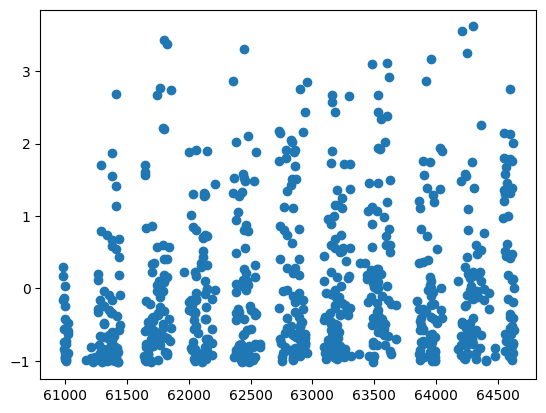

In [ ]:
# print(df.loc[0, "lightcurve"][["mjd", "flux_perfect"]])


data = jnp.asarray(df.loc[0, "lightcurve"][["mjd", "flux_perfect"]].to_numpy())

print(jnp.shape(data))

x = data[:, 0]
y = data[:, 1]
y_mean = jnp.mean(y)
y_sd = jnp.std(y)
y_standarized = (y - y_mean) / y_sd


plt.scatter(data[:, 0], y_standarized)

print(jnp.std(y_standarized))


That scatterplot is really discouraging. The information content doe snot seem great...

(Array(-11.109364, dtype=float32), Array(-4.24255, dtype=float32), Array(0.00041025, dtype=float32))
[-8.58184279e-09 -2.33484343e-11  1.82083699e-08 -1.31324214e-08
 -1.29095028e-08 -6.59163391e-08 -3.55409568e-08 -4.98941048e-08
 -7.39791659e-08 -1.72292403e-10 -1.65233782e-08 -1.03440456e-08
 -8.20147790e-08 -2.34481270e-08 -6.91333568e-08 -7.55452092e-08
 -3.89940169e-09 -3.03599919e-08  7.77987452e-10 -4.33922480e-08
 -8.44156887e-08 -1.52713540e-08  2.02024353e-09 -3.56395589e-08
 -4.90542220e-08 -8.19118569e-08 -5.22465058e-08 -7.20175066e-08
 -3.31251471e-08  1.66870961e-08 -6.30646682e-08 -1.73524981e-08
 -2.04623696e-08  6.06643891e-09  7.17365545e-09 -4.70619312e-08
 -4.41175629e-08 -5.63996778e-08 -9.35711952e-09 -6.13620728e-08
 -1.59862878e-08 -3.57091494e-08  7.85303484e-08  7.65563897e-08
 -1.70498780e-08 -4.22572128e-08 -3.48103271e-08 -3.14940891e-08
 -3.14982636e-08 -7.92847388e-08 -1.04361533e-08 -1.79484427e-09
 -4.55707223e-08 -1.70354042e-08 -8.13825949e-08  8.48

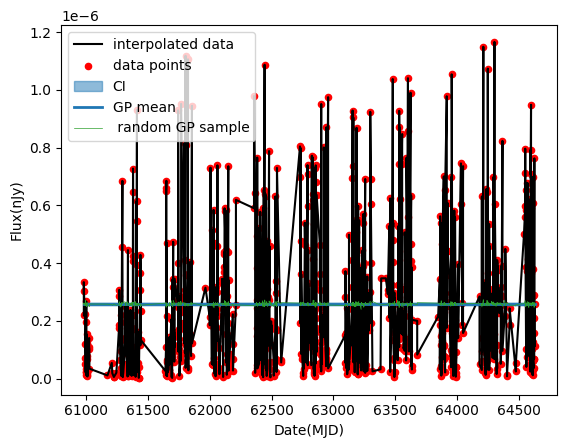

In [35]:
scale = Param("scale", value=100.0, shape=(), description="scale parameter")
sigma = Param("sigma", value=1, shape=(), description="sigma parameter")
noise = Param("noise", value=0.01, shape=(), description="noise parameter")



theta = (jnp.log(float(sigma.value)), jnp.log(float(scale.value)), jnp.log(float(noise.value)))

soln = solver.run(theta, X=x, y=y_standarized)

gp = build_gp(soln.params, x)

print(soln.params)

cond_gp = gp.condition(y_standarized).gp


mu, var = cond_gp.loc, cond_gp.variance

print(mu)



plt.plot(x, y_mean + y_sd * y_standarized, color = "k")
plt.scatter(x, y_mean + y_sd * y_standarized, color="red", s=20)
plt.fill_between(x, y_mean + y_sd * (mu + np.sqrt(var)), y_mean + y_sd * (mu - np.sqrt(var)), color="C0", alpha=0.5)
plt.plot(x, y_mean + y_sd * mu, color="C0", lw=2)
plt.plot(x, y_mean + y_sd * cond_gp.sample(jax.random.PRNGKey(42)), color="C2", lw=0.5)
plt.legend(["interpolated data", "data points", "CI", "GP mean", " random GP sample"])
plt.xlabel("Date(MJD)")
_ = plt.ylabel("Flux(nJy)")

My theory is that all of the variance is getting absorbed as noice. Hence, I will try fixing the noise parameter to hopefully force the gp to interpret the spikes as signal variance. 

(Array(-0.08072317, dtype=float32), Array(-5.9653335, dtype=float32))
[-1.46283478e-01  2.76392221e-01  1.58815682e-01 -1.25595808e-01
 -5.07754445e-01 -6.81863725e-01 -7.65986562e-01 -8.23035359e-01
 -8.68189514e-01  3.09906397e-02 -2.23824546e-01 -8.69394720e-01
 -9.00547504e-01 -3.84775102e-01 -6.64523423e-01 -8.78489316e-01
 -9.07152057e-01 -6.99503660e-01 -4.98022884e-01 -8.61464083e-01
 -9.23086584e-01 -4.32241172e-01 -5.45175552e-01 -5.75324953e-01
 -8.20910931e-01 -9.06502903e-01 -7.47967243e-01 -8.78994882e-01
 -9.25067604e-01 -9.26459253e-01 -8.72993469e-01 -2.96754003e-01
 -2.96753973e-01  1.48445249e-01  1.48445278e-01 -7.16379523e-01
 -9.02676463e-01 -6.00956976e-01 -1.46604016e-01 -9.00848746e-01
 -8.18216324e-01 -9.12840426e-01  1.56075513e+00  7.27838039e-01
 -8.35514903e-01 -9.28262711e-01 -8.76364768e-01 -7.64956176e-01
 -4.34665352e-01 -6.19095206e-01 -2.24316150e-01 -2.98733376e-02
 -4.51843888e-01 -8.69980514e-01 -9.19936717e-01  6.82270646e-01
 -8.57201636e-01 -9.

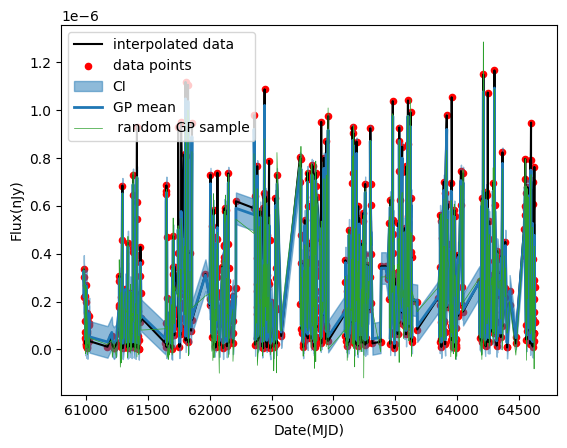

In [36]:
def build_gp_var_fixed(theta: tuple[Param], x: jnp.ndarray) -> GaussianProcess:
    """ Build a Gaussian Process with the given parameters and input data.
    Precondition: theta is a tuple of (log_sigma, log_scale) parameters.
    """
    log_sigma, log_scale = theta
    kernel = kernels.quasisep.Exp(scale=jnp.exp(log_scale), sigma=jnp.exp(log_sigma))
    return GaussianProcess(kernel, x, diag=0.075)


def neg_log_likelihood_var_fixed(theta, X, y):
    gp = build_gp_var_fixed(theta, X)
    return -gp.log_probability(y)

solver = jaxopt.ScipyMinimize(fun=neg_log_likelihood_var_fixed)

scale = Param("scale", value=100.0, shape=(), description="scale parameter")
sigma = Param("sigma", value=1, shape=(), description="sigma parameter")

theta = (jnp.log(float(sigma.value)), jnp.log(float(scale.value)))

soln = solver.run(theta, X=x, y=y_standarized)

gp = build_gp_var_fixed(soln.params, x)

print(soln.params)

cond_gp = gp.condition(y_standarized).gp


mu, var = cond_gp.loc, cond_gp.variance

print(mu)



plt.plot(x, y_mean + y_sd * y_standarized, color = "k")
plt.scatter(x, y_mean + y_sd * y_standarized, color="red", s=20)
plt.fill_between(x, y_mean + y_sd * (mu + np.sqrt(var)), y_mean + y_sd * (mu - np.sqrt(var)), color="C0", alpha=0.5)
plt.plot(x, y_mean + y_sd * mu, color="C0", lw=2)
plt.plot(x, y_mean + y_sd * cond_gp.sample(jax.random.PRNGKey(42)), color="C2", lw=0.5)
plt.legend(["interpolated data", "data points", "CI", "GP mean", " random GP sample"])
plt.xlabel("Date(MJD)")
_ = plt.ylabel("Flux(nJy)")

The most obvios problem is that it predicts negative fluxes, which does not make sense in the context of the problem. I'm going to try taking the log and then the exponent. 

In [37]:
# assert jnp.all(y > 0), "y contains non-positive values, cannot take log"

# # y -> normalization -> log transform -> prediction 

# y_st = y/y_mean

# x_mean = jnp.mean(x)
# x_std = jnp.std(x)
# x_standarized = (x - x_mean)/x_std

# y_log = jnp.log(y_st)

# print(jnp.mean(y_log), jnp.std(y_log), jnp.min(y_log), jnp.max(y_log))

# def build_gp_var_fixed(theta: tuple[Param], x: jnp.ndarray) -> GaussianProcess:
#     """ Build a Gaussian Process with the given parameters and input data.
#     Precondition: theta is a tuple of (log_sigma, log_scale) parameters.
#     """
#     log_sigma, log_scale = theta
#     kernel = kernels.quasisep.Matern32(scale=jnp.exp(log_scale), sigma=jnp.exp(log_sigma))
#     return GaussianProcess(kernel, x, diag=0.5, mean =jnp.mean(y_log))



# scale = Param("scale", value= 0.5, shape=(), description="scale parameter")
# sigma = Param("sigma", value=1, shape=(), description="sigma parameter")

# theta = (jnp.log(float(sigma.value)), jnp.log(float(scale.value)))

# soln = solver.run(theta, X=x_standarized, y=y_log)

# gp = build_gp_var_fixed(soln.params, x_standarized)

# print(soln.params)

# cond_gp = gp.condition(y_log).gp

# mu, var = cond_gp.loc, cond_gp.variance

# print(mu, var)

# sample = jnp.exp(cond_gp.sample(jax.random.PRNGKey(42)))
# print(sample)
# print(jnp.shape(sample))
# print(jnp.min(sample), jnp.max(sample))
# print(jnp.any(jnp.isnan(sample)))


# plt.plot(x_standarized, y, color = "k")
# plt.scatter(x_standarized, y, color="red", s=20)
# plt.fill_between(x_standarized, jnp.exp(mu + jnp.sqrt(var)) * y_mean, jnp.exp(mu - jnp.sqrt(var)) * y_mean, color="C0", alpha=0.5)
# plt.plot(x_standarized, jnp.exp(mu) * y_mean, color="C0", lw=2)
# plt.plot(x_standarized, sample * y_mean, color="C2", lw=0.5)
# plt.legend(["interpolated data", "data points", "CI", "GP mean", " random GP sample"])
# plt.xlabel("Date(MJD)")
# _ = plt.ylabel("Flux(nJy)")


Doing it in the log space is not working, I keep getting nans no matter what I try. I am going to patch it by clipping it for now, and I will see how to solve it later on. 

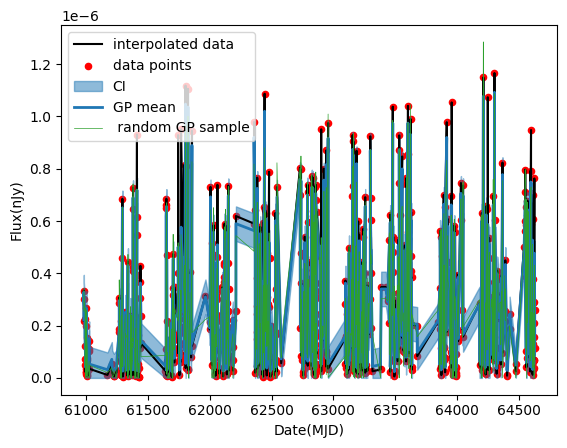

In [38]:
# TODO FInd an alternative to clipping, especially not this way, where I clip the final output instead of all possible sample. 

plt.plot(x, y_mean + y_sd * y_standarized, color = "k")
plt.scatter(x, y_mean + y_sd * y_standarized, color="red", s=20)
plt.fill_between(x, y_mean + y_sd * (mu + np.sqrt(var)), jnp.clip(y_mean + y_sd * (mu - np.sqrt(var)), 0.0, None), color="C0", alpha=0.5)
plt.plot(x, y_mean + y_sd * mu, color="C0", lw=2)
plt.plot(x, jnp.clip(y_mean + y_sd * cond_gp.sample(jax.random.PRNGKey(42)), 0.0, None), color="C2", lw=0.5)
plt.legend(["interpolated data", "data points", "CI", "GP mean", " random GP sample"])
plt.xlabel("Date(MJD)")
_ = plt.ylabel("Flux(nJy)")

Log space attempt number 10000!! (fingers crossed!)

(Array(0.3284457, dtype=float32), Array(-3.87853, dtype=float32))
[-1.64746135e-01  2.52300829e-01  1.53290048e-01 -1.43276766e-01
 -7.58708596e-01 -1.26265895e+00 -1.63290143e+00 -2.01063967e+00
 -2.44556665e+00  3.08200400e-02 -2.66109824e-01 -2.46767330e+00
 -2.95461988e+00 -5.18403351e-01 -1.19530606e+00 -2.59469867e+00
 -3.11405778e+00 -1.32616460e+00 -7.41441786e-01 -2.35518527e+00
 -3.48108172e+00 -6.04440749e-01 -8.48104179e-01 -9.29102421e-01
 -1.98963642e+00 -3.09535980e+00 -1.53968942e+00 -2.59254742e+00
 -3.69038105e+00 -3.75186849e+00 -2.51007247e+00 -3.55080307e-01
 -3.55080426e-01  1.37757674e-01  1.37757495e-01 -1.39461243e+00
 -3.00819111e+00 -1.00436783e+00 -1.74863577e-01 -2.96727085e+00
 -1.97733247e+00 -3.26236415e+00  9.64074075e-01  5.66235065e-01
 -2.12076831e+00 -3.83229995e+00 -2.55555534e+00 -1.62750876e+00
 -6.10213101e-01 -1.04860663e+00 -2.67022491e-01 -3.49435993e-02
 -6.40134931e-01 -2.48092866e+00 -3.48661399e+00  5.29318690e-01
 -2.31773043e+00 -3.0676

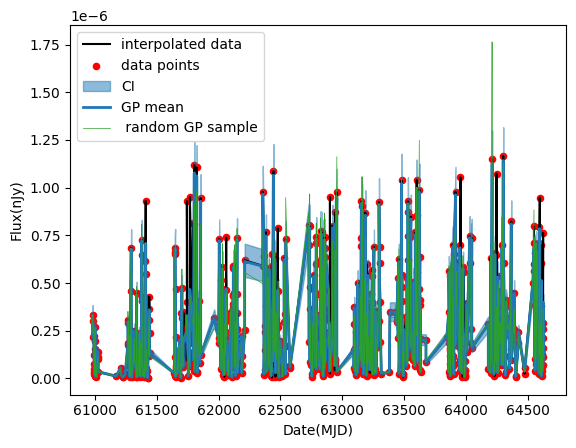

In [39]:
y_stand = y/y_mean

y_log = jnp.log(y_stand)

assert jnp.all(y_stand > 0), "y_stand contains non-positive values, cannot take log"

def build_gp_var_fixed(theta: tuple[Param], x: jnp.ndarray) -> GaussianProcess:
    """ Build a Gaussian Process with the given parameters and input data.
    Precondition: theta is a tuple of (log_sigma, log_scale) parameters.
    """
    log_sigma, log_scale = theta
    kernel = kernels.quasisep.Exp(scale=jnp.exp(log_scale), sigma=jnp.exp(log_sigma))
    return GaussianProcess(kernel, x, diag=0.02)


def neg_log_likelihood_var_fixed(theta, X, y):
    gp = build_gp_var_fixed(theta, X)
    return -gp.log_probability(y)

solver = jaxopt.ScipyMinimize(fun=neg_log_likelihood_var_fixed)

scale = Param("scale", value=jnp.log(100.0), shape=(), description="scale parameter")
sigma = Param("sigma", value=jnp.log(1.01), shape=(), description="sigma parameter")

theta = (jnp.log(float(sigma.value)), jnp.log(float(scale.value)))

soln = solver.run(theta, X=x, y=y_log)

gp = build_gp_var_fixed(soln.params, x)

print(soln.params)

cond_gp = gp.condition(y_log).gp


mu, var = cond_gp.loc, cond_gp.variance

print(mu)



plt.plot(x, y, color = "k")
plt.scatter(x, y, color="red", s=20)
plt.fill_between(x, y_mean * jnp.exp(mu + np.sqrt(var)), y_mean  * jnp.exp(mu - np.sqrt(var)), color="C0", alpha=0.5)
plt.plot(x, y_mean * jnp.exp(mu), color="C0", lw=2)
plt.plot(x, y_mean * jnp.exp(cond_gp.sample(jax.random.PRNGKey(42))), color="C2", lw=0.5)
plt.legend(["interpolated data", "data points", "CI", "GP mean", " random GP sample"])
plt.xlabel("Date(MJD)")
_ = plt.ylabel("Flux(nJy)")